# FHIRscan — DIZ-Vergleichsanalyse

Vergleicht die Profiling-Outputs von bis zu **6 Datenintegrationszentren (DIZ)**.  
Jedes DIZ entspricht einem Ordner, den `main.py` erzeugt hat.

**Struktur:**
1. Datensatz-Übersicht (Ressourcenzahlen)
2. Vollständigkeitsanalyse (Presence Rates) — Heatmaps pro Ressourcentyp
3. Datenqualität (Patient/Encounter-Linkage)
4. Kardinalitätsvergleich
5. Größte Abweichungen zwischen DIZ
6. Wertverteilung für kodierte Felder

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.3f}'.format)

## ⚙️ Konfiguration

Trage hier die **Output-Ordner** der 6 DIZ ein (die timestamped Unterordner von `Output/`).  
Nicht verwendete Einträge einfach auskommentieren oder leer lassen.

In [2]:
# ── Konfiguration: Namen und Pfade der DIZ ────────────────────────────────
# Schlüssel = Anzeigename des DIZ  │  Wert = Pfad zum Output-Ordner

BASE = Path("..")   # Projekt-Root (relativ zum Notebook in Code/)

DIZ = {
    "MI-I Testdaten": BASE / "Output"   / "20260520_14_45",
    "Würzburg Testserver":             BASE / "Analysis" / "Würzburg_01",
    "Würzburg großer Server":             BASE / "Analysis" / "Würzburg_02",
    # "UKA": BASE / "Analysis" / "Augsburg_01",
    # "FAU": BASE / "Analysis" / "Erlangen_01",
}

# Farben pro DIZ (automatisch erweitert wenn mehr als 6)
DIZ_COLORS = px.colors.qualitative.Bold
COLOR_MAP = {name: DIZ_COLORS[i % len(DIZ_COLORS)] for i, name in enumerate(DIZ)}

print(f"Konfigurierte DIZ: {list(DIZ.keys())}")

Konfigurierte DIZ: ['MI-I Testdaten', 'Würzburg Testserver', 'Würzburg großer Server']


## 📥 Daten laden

In [3]:
def load_csv_safe(path: Path, diz_name: str) -> pd.DataFrame:
    """Lädt eine CSV, gibt leeren DataFrame zurück wenn Datei fehlt."""
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df["diz"] = diz_name
    return df


def load_fields(folder: Path, diz_name: str) -> pd.DataFrame:
    """Lädt alle *_fields.csv aus einem Ordner und kombiniert sie."""
    dfs = []
    for csv_file in sorted(folder.glob("*_fields.csv")):
        resource_type = csv_file.stem.replace("_fields", "")
        df = pd.read_csv(csv_file)
        df["diz"] = diz_name
        df["resource_type"] = resource_type
        for col in ["presence_rate", "missing_rate"]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


def parse_top_values(tv_str) -> dict:
    """Parst den top_values JSON-String zu einem {wert: count}-Dict."""
    if pd.isna(tv_str) or tv_str == "":
        return {}
    try:
        pairs = json.loads(tv_str)
        return {str(k): int(v) for k, v in pairs}
    except Exception:
        return {}


# ── Alle Daten laden ──────────────────────────────────────────────────────
summary_frames, quality_frames, card_frames, fields_frames = [], [], [], []
missing_folders = []
load_log = {}   # diz_name -> dict mit Datei-Status

CORE_FILES = {
    "summary":     "01_summary.csv",
    "cardinality": "03_cardinality.csv",
    "quality":     "04_data_quality.csv",
}

for diz_name, folder in DIZ.items():
    if not folder.exists():
        missing_folders.append((diz_name, str(folder)))
        print(f"⚠️  Ordner nicht gefunden: {diz_name} → {folder}")
        continue

    log = {}
    for key, filename in CORE_FILES.items():
        path = folder / filename
        log[filename] = "✅" if path.exists() else "❌ FEHLT"

    fields_files = sorted(folder.glob("*_fields.csv"))
    log["*_fields.csv"] = f"✅ {len(fields_files)} Dateien"

    load_log[diz_name] = log

    summary_frames.append(load_csv_safe(folder / "01_summary.csv",      diz_name))
    quality_frames.append(load_csv_safe(folder / "04_data_quality.csv",  diz_name))
    card_frames.append(   load_csv_safe(folder / "03_cardinality.csv",   diz_name))
    fields_frames.append(load_fields(folder, diz_name))

df_summary  = pd.concat(summary_frames,  ignore_index=True) if summary_frames  else pd.DataFrame()
df_quality  = pd.concat(quality_frames,  ignore_index=True) if quality_frames  else pd.DataFrame()
df_card     = pd.concat(card_frames,     ignore_index=True) if card_frames     else pd.DataFrame()
df_fields   = pd.concat(fields_frames,   ignore_index=True) if fields_frames   else pd.DataFrame()

for col in ["coverage_rate", "mean", "median", "std_dev", "min", "max", "p25", "p75", "p90", "p99"]:
    if col in df_card.columns:
        df_card[col] = pd.to_numeric(df_card[col], errors="coerce")

LOADED_DIZ = [d for d in DIZ if d not in [m[0] for m in missing_folders]]
ALL_RT = sorted(df_summary["resource_type"].unique()) if not df_summary.empty else []

print(f"✅ Geladen: {len(LOADED_DIZ)} DIZ, {len(ALL_RT)} Ressourcentypen")
print(f"   Ressourcentypen: {ALL_RT}")
print(f"   Felder gesamt:   {len(df_fields):,} Einträge\n")

print("── Dateien pro DIZ ──────────────────────────────────────────────────")
for diz_name, log in load_log.items():
    n_fields_rows = len(df_fields[df_fields["diz"] == diz_name]) if not df_fields.empty else 0
    n_rt = len(df_summary[df_summary["diz"] == diz_name]["resource_type"].unique()) if not df_summary.empty else 0
    print(f"\n  {diz_name}")
    for filename, status in log.items():
        print(f"    {status}  {filename}")
    print(f"    → {n_rt} Ressourcentypen, {n_fields_rows:,} Feldeinträge eingelesen")

✅ Geladen: 3 DIZ, 18 Ressourcentypen
   Ressourcentypen: ['AdverseEvent', 'CarePlan', 'ClinicalImpression', 'Composition', 'Condition', 'Consent', 'DiagnosticReport', 'Encounter', 'List', 'Location', 'Medication', 'MedicationAdministration', 'MedicationRequest', 'MedicationStatement', 'Observation', 'Patient', 'Procedure', 'Specimen']
   Felder gesamt:   1,441 Einträge

── Dateien pro DIZ ──────────────────────────────────────────────────

  MI-I Testdaten
    ✅  01_summary.csv
    ✅  03_cardinality.csv
    ✅  04_data_quality.csv
    ✅ 9 Dateien  *_fields.csv
    → 9 Ressourcentypen, 269 Feldeinträge eingelesen

  Würzburg Testserver
    ✅  01_summary.csv
    ✅  03_cardinality.csv
    ✅  04_data_quality.csv
    ✅ 7 Dateien  *_fields.csv
    → 7 Ressourcentypen, 255 Feldeinträge eingelesen

  Würzburg großer Server
    ✅  01_summary.csv
    ✅  03_cardinality.csv
    ✅  04_data_quality.csv
    ✅ 17 Dateien  *_fields.csv
    → 17 Ressourcentypen, 917 Feldeinträge eingelesen


In [4]:
# ── Report-Header ─────────────────────────────────────────────────────────
from datetime import datetime
from IPython.display import display, HTML

_now = datetime.now().strftime("%d.%m.%Y %H:%M")

_res_per_diz = (
    df_summary.groupby("diz")["total_resources"].sum()
    if not df_summary.empty else pd.Series(dtype=int)
)
_pat_per_diz = (
    df_summary[df_summary["resource_type"] == "Patient"]
    .set_index("diz")["total_resources"]
    if not df_summary.empty else pd.Series(dtype=int)
)

_rows = "".join(
    f"<tr><td style='padding:5px 12px'>{diz}</td>"
    f"<td style='text-align:right;padding:5px 12px'>{_res_per_diz.get(diz, 0):,}</td>"
    f"<td style='text-align:right;padding:5px 12px'>{int(_pat_per_diz.get(diz, 0)):,}</td></tr>"
    for diz in LOADED_DIZ
)

display(HTML(f"""
<div style="border:1px solid #d0d0d0;border-radius:8px;padding:20px 28px;
            background:#f7f9fc;font-family:sans-serif;max-width:720px">
  <h2 style="margin-top:0;color:#1a1a2e">FHIRscan &mdash; DIZ-Vergleichsreport</h2>
  <p style="color:#666;margin:0 0 14px 0">Generiert am <b>{_now}</b></p>
  <table style="border-collapse:collapse;width:100%;background:#fff;
                border:1px solid #e0e0e0;border-radius:4px">
    <tr style="background:#eef2f7">
      <th style="text-align:left;padding:6px 12px;font-weight:600">DIZ</th>
      <th style="text-align:right;padding:6px 12px;font-weight:600">Ressourcen gesamt</th>
      <th style="text-align:right;padding:6px 12px;font-weight:600">Patienten gesamt</th>
    </tr>
    {_rows}
  </table>
  <p style="margin:14px 0 0 0;color:#555;font-size:0.95em">
    <b>{len(LOADED_DIZ)}&thinsp;DIZ</b> &nbsp;&middot;&nbsp;
    <b>{len(ALL_RT)}&thinsp;Ressourcentypen</b> &nbsp;&middot;&nbsp;
    <b>{df_fields["field_path"].nunique():,}&thinsp;FHIR-Elemente</b>
  </p>
</div>
"""))


DIZ,Ressourcen gesamt,Patienten gesamt
MI-I Testdaten,"81,679","12,101"
Würzburg Testserver,"23,957,139","1,766,849"
Würzburg großer Server,"307,749,847","1,559,225"


---
## 1. Datensatz-Übersicht

In [5]:
# ── 1a. Ressourcenzahlen pro DIZ ─────────────────────────────────────────
if not df_summary.empty:
    _vals = np.sort(df_summary["total_resources"].values.astype(float))
    _gaps = np.diff(_vals) / (_vals[:-1] + 1)
    _bi = int(np.argmax(_gaps))
    _needs_break = len(_gaps) > 0 and _gaps[_bi] > 2.0

    if _needs_break:
        _break_lo = _vals[_bi] * 1.15
        _break_hi = _vals[_bi + 1] * 0.85
        _y_max    = _vals[-1] * 1.05

        fig = make_subplots(
            rows=2, cols=1, shared_xaxes=True,
            vertical_spacing=0.06,
            row_heights=[0.2, 0.8]
        )
        for diz_name in LOADED_DIZ:
            sub = df_summary[df_summary["diz"] == diz_name]
            kw = dict(
                name=diz_name,
                x=sub["resource_type"].tolist(),
                y=sub["total_resources"].tolist(),
                marker_color=COLOR_MAP[diz_name],
                offsetgroup=diz_name,
            )
            fig.add_trace(go.Bar(**kw, showlegend=False, legendgroup=diz_name), row=1, col=1)
            fig.add_trace(go.Bar(**kw, showlegend=True,  legendgroup=diz_name), row=2, col=1)

        fig.update_yaxes(range=[_break_hi, _y_max], row=1, col=1)
        fig.update_yaxes(range=[0, _break_lo],      row=2, col=1, title_text="Anzahl Ressourcen")
        fig.update_xaxes(tickangle=-30)

        # Break-Markierungen an der Y-Achse (diagonale Linien)
        _avail    = 1.0 - 0.06
        _y_lo_top = 0.8 * _avail            # oberes Ende des unteren Panels
        _y_hi_bot = _y_lo_top + 0.06        # unteres Ende des oberen Panels
        _dw, _dh  = 0.012, 0.010
        for _yc in [_y_lo_top, _y_hi_bot]:
            for _xc in [0.02, 0.05]:
                fig.add_shape(
                    type="line", xref="paper", yref="paper",
                    x0=_xc - _dw, y0=_yc - _dh,
                    x1=_xc + _dw, y1=_yc + _dh,
                    line=dict(color="gray", width=2),
                )

        fig.update_layout(
            barmode="group", height=520, legend_title="DIZ",
            title_text="Ressourcenzahlen je Ressourcentyp und DIZ",
        )
    else:
        fig = px.bar(
            df_summary,
            x="resource_type", y="total_resources", color="diz",
            barmode="group", color_discrete_map=COLOR_MAP,
            title="Ressourcenzahlen je Ressourcentyp und DIZ",
            labels={"total_resources": "Anzahl Ressourcen", "resource_type": "Ressourcentyp", "diz": "DIZ"},
            height=450,
        )
        fig.update_layout(xaxis_tickangle=-30)

    fig.show()


In [6]:
# ── 1b. Feldstruktur-Übersicht ────────────────────────────────────────────
# Gestapelter Balken: Immer / Manchmal / Nie — DIZ nebeneinander.
# Farbe = Kategorie, Muster = DIZ (6 Muster für bis zu 6 DIZ).
if not df_fields.empty:
    scalar = df_fields[
        ~df_fields["detected_python_types"].str.fullmatch(r"object|array", na=False)
    ].copy()

    def classify_pr(pr):
        if pr == 1.0: return "Immer (100 %)"
        if pr > 0:    return "Manchmal (1–99 %)"
        return "Nie (0 %)"

    scalar["cls"] = scalar["presence_rate"].apply(classify_pr)

    CATS    = ["Immer (100 %)", "Manchmal (1–99 %)", "Nie (0 %)"]
    CAT_CLR = {"Immer (100 %)": "#2ecc71", "Manchmal (1–99 %)": "#f1c40f", "Nie (0 %)": "#e74c3c"}
    HATCH   = ["", "/", "\\", "x", "-", "|"]   # ein Muster je DIZ, deckt 6 DIZ ab

    counts = (
        scalar.groupby(["diz", "resource_type", "cls"])
        .size()
        .unstack("cls", fill_value=0)
        .reindex(columns=CATS, fill_value=0)
        .reset_index()
    )
    counts["total"] = counts[CATS].sum(axis=1)

    fig = go.Figure()

    for cat in CATS:
        for j, diz_name in enumerate(LOADED_DIZ):
            sub = counts[counts["diz"] == diz_name].copy()
            pct = (sub[cat] / sub["total"].replace(0, 1) * 100).round(1).tolist()
            fig.add_trace(go.Bar(
                name=cat,
                x=sub["resource_type"].tolist(),
                y=sub[cat].tolist(),
                offsetgroup=diz_name,
                legendgroup=cat,
                showlegend=(j == 0),
                marker=dict(
                    color=CAT_CLR[cat],
                    pattern=dict(shape=HATCH[j % len(HATCH)], fgcolor="rgba(0,0,0,0.25)"),
                ),
                customdata=list(zip(pct, [diz_name] * len(sub))),
                hovertemplate=(
                    "<b>%{customdata[1]}</b><br>"
                    f"{cat}: %{{y}} Felder (%{{customdata[0]}} %)"
                    "<extra></extra>"
                ),
            ))

    # Dummy-Traces für DIZ-Legende
    for j, diz_name in enumerate(LOADED_DIZ):
        fig.add_trace(go.Bar(
            x=[None], y=[0],
            name=diz_name,
            legendgroup=f"_diz{j}",
            legendgrouptitle_text="DIZ" if j == 0 else "",
            marker=dict(
                color="lightgrey",
                pattern=dict(shape=HATCH[j % len(HATCH)], fgcolor="rgba(0,0,0,0.45)"),
            ),
        ))

    fig.update_layout(
        barmode="stack",
        height=500,
        width=max(900, len(ALL_RT) * len(LOADED_DIZ) * 65 + 250),
        title_text="Feldstruktur je Ressourcentyp und DIZ",
        xaxis=dict(title="Ressourcentyp", tickangle=-30),
        yaxis_title="Anzahl Felder",
        bargroupgap=0.12,
        legend=dict(tracegroupgap=10),
    )
    fig.show()
else:
    print("Keine Felddaten verfügbar.")

---
## 2. Vollständigkeitsanalyse (Presence Rates)

Heatmap: Zeilen = Felder, Spalten = DIZ, Farbe = `presence_rate` (0 = nie vorhanden, 1 = immer vorhanden).  
Nur skalare Felder werden angezeigt (keine reinen Objekt-/Array-Knoten).

In [7]:
def presence_heatmap(resource_type: str, min_presence_any_diz: float = 0.0):
    """
    Zeichnet eine Presence-Rate-Heatmap für einen Ressourcentyp.
    min_presence_any_diz: Felder werden nur angezeigt wenn mindestens ein DIZ
                           diesen Wert überschreitet (filtert reine Nullzeilen).
    """
    sub = df_fields[
        (df_fields["resource_type"] == resource_type) &
        # Nur skalare Felder: kein reines object/array ohne weiteren Typ
        (~df_fields["detected_python_types"].str.fullmatch(r"object|array", na=False))
    ].copy()

    if sub.empty:
        print(f"Keine skalaren Felder für {resource_type} gefunden.")
        return

    pivot = sub.pivot_table(
        index="field_path", columns="diz",
        values="presence_rate", aggfunc="first"
    ).reindex(columns=LOADED_DIZ)

    # Filter: nur Felder die in mindestens einem DIZ > min_presence_any_diz sind
    pivot = pivot[pivot.max(axis=1) > min_presence_any_diz]

    if pivot.empty:
        print(f"Keine Felder über Schwellwert {min_presence_any_diz} für {resource_type}.")
        return

    # Sortierung: nach mittlerer Presence Rate (absteigend)
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    height = max(400, len(pivot) * 22 + 100)

    fig = px.imshow(
        pivot,
        color_continuous_scale="RdYlGn",
        zmin=0, zmax=1,
        aspect="auto",
        title=f"Presence Rate — {resource_type}  ({len(pivot)} Felder)",
        labels={"color": "Presence Rate"},
        height=height
    )
    fig.update_xaxes(side="top")
    fig.update_layout(coloraxis_colorbar_title="Rate")
    fig.show()


# ── Heatmap für alle Ressourcentypen ─────────────────────────────────────
for rt in ALL_RT:
    presence_heatmap(rt, min_presence_any_diz=0.01)

In [8]:
# ── 2b. Abweichungs-Heatmap: Differenz von DIZ-Wert zum DIZ-Mittel ───────
# Grün = DIZ hat höhere Presence Rate als Durchschnitt, Rot = niedriger

def delta_heatmap(resource_type: str):
    sub = df_fields[
        (df_fields["resource_type"] == resource_type) &
        (~df_fields["detected_python_types"].str.fullmatch(r"object|array", na=False))
    ].copy()

    if sub.empty:
        return

    pivot = sub.pivot_table(
        index="field_path", columns="diz",
        values="presence_rate", aggfunc="first"
    ).reindex(columns=LOADED_DIZ)

    # Nur Felder mit Varianz zwischen DIZ
    row_std = pivot.std(axis=1)
    pivot = pivot[row_std > 0.01]
    if pivot.empty:
        print(f"{resource_type}: Keine signifikanten Abweichungen zwischen DIZ.")
        return

    delta = pivot.sub(pivot.mean(axis=1), axis=0)
    delta = delta.loc[pivot.std(axis=1).sort_values(ascending=False).index]

    height = max(400, len(delta) * 22 + 100)

    fig = px.imshow(
        delta,
        color_continuous_scale="RdBu",
        color_continuous_midpoint=0,
        aspect="auto",
        title=f"Abweichung vom DIZ-Mittel — {resource_type}  ({len(delta)} Felder mit Varianz)",
        labels={"color": "Δ Presence Rate"},
        height=height
    )
    fig.update_xaxes(side="top")
    fig.show()


for rt in ALL_RT:
    delta_heatmap(rt)

AdverseEvent: Keine signifikanten Abweichungen zwischen DIZ.
CarePlan: Keine signifikanten Abweichungen zwischen DIZ.
ClinicalImpression: Keine signifikanten Abweichungen zwischen DIZ.
Composition: Keine signifikanten Abweichungen zwischen DIZ.


DiagnosticReport: Keine signifikanten Abweichungen zwischen DIZ.


List: Keine signifikanten Abweichungen zwischen DIZ.
Location: Keine signifikanten Abweichungen zwischen DIZ.


MedicationRequest: Keine signifikanten Abweichungen zwischen DIZ.


Specimen: Keine signifikanten Abweichungen zwischen DIZ.


---
## 3. Datenqualität — Patient & Encounter Linkage

In [9]:
if not df_quality.empty:
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=["Patient Linkage Rate", "Encounter Linkage Rate"]
    )

    for diz_name in LOADED_DIZ:
        sub = df_quality[df_quality["diz"] == diz_name]
        show_legend = (diz_name == LOADED_DIZ[0])

        fig.add_trace(go.Bar(
            name=diz_name, x=sub["resource_type"].tolist(), y=sub["patient_linkage_rate"].tolist(),
            marker_color=COLOR_MAP[diz_name], showlegend=True
        ), row=1, col=1)

        fig.add_trace(go.Bar(
            name=diz_name, x=sub["resource_type"].tolist(), y=sub["encounter_linkage_rate"].tolist(),
            marker_color=COLOR_MAP[diz_name], showlegend=False
        ), row=1, col=2)

    fig.update_yaxes(range=[0, 1.05], tickformat=".0%")
    fig.update_layout(
        barmode="group", height=430,
        title_text="Datenqualität: Verlinkungsraten je Ressourcentyp und DIZ",
        legend_title="DIZ"
    )
    fig.show()

    # Tabelle: Wer hat die niedrigste Patient-Linkage-Rate?
    print("\n⚠️  Niedrige Patient-Linkage-Raten (< 0.8):")
    low = df_quality[df_quality["patient_linkage_rate"] < 0.8][["diz", "resource_type", "patient_linkage_rate", "total_resources"]]
    if low.empty:
        print("   Keine gefunden.")
    else:
        display(low.sort_values("patient_linkage_rate"))
else:
    print("Keine _data_quality.csv Daten geladen.")


⚠️  Niedrige Patient-Linkage-Raten (< 0.8):


,diz,resource_type,patient_linkage_rate,total_resources
3,MI-I Testdaten,Medication,0.000,242
7,MI-I Testdaten,Patient,0.000,12101
12,Würzburg Testserver,Location,0.000,678
14,Würzburg Testserver,Patient,0.000,1766849
25,Würzburg großer Server,Medication,0.000,249766
30,Würzburg großer Server,Patient,0.000,1559225


---
## 4. Kardinalitätsvergleich

Wie viele Ressourcen eines Typs hat ein Patient/Encounter durchschnittlich — im Vergleich zwischen DIZ?

In [10]:
if not df_card.empty:
    for anchor in df_card["anchor_type"].unique():
        sub = df_card[df_card["anchor_type"] == anchor].copy()

        anchor_label = "Patient" if "patient" in anchor else "Encounter"

        fig = make_subplots(
            rows=1, cols=2,
            subplot_titles=[f"Mittlere Anzahl je {anchor_label}", f"Coverage Rate (≥1 Ressource)"]
        )

        for diz_name in LOADED_DIZ:
            d = sub[sub["diz"] == diz_name]
            # Mean mit Fehlerbalken (std_dev)
            fig.add_trace(go.Bar(
                name=diz_name, x=d["resource_type"], y=d["mean"],
                error_y=dict(type="data", array=d["std_dev"].fillna(0).tolist()),
                marker_color=COLOR_MAP[diz_name],
                showlegend=True
            ), row=1, col=1)

            fig.add_trace(go.Bar(
                name=diz_name, x=d["resource_type"], y=d["coverage_rate"],
                marker_color=COLOR_MAP[diz_name],
                showlegend=False
            ), row=1, col=2)

        fig.update_layout(
            barmode="group", height=430,
            title_text=f"Kardinalität: {anchor}",
            legend_title="DIZ"
        )
        fig.update_yaxes(tickformat=".0%", row=1, col=2)
        fig.show()

    # Detailtabelle: Perzentile im Vergleich
    print("\nKardinalitäts-Detailtabelle (per_patient):")
    detail_cols = ["diz", "resource_type", "total_resources", "min", "mean", "median", "max", "p90", "p99", "coverage_rate"]
    available = [c for c in detail_cols if c in df_card.columns]
    display(
        df_card[df_card["anchor_type"] == "per_patient"][available]
        .sort_values(["resource_type", "diz"])
        .reset_index(drop=True)
    )
else:
    print("Keine _cardinality.csv Daten geladen.")


Kardinalitäts-Detailtabelle (per_patient):


,diz,resource_type,total_resources,min,mean,median,max,p90,p99,coverage_rate
0,Würzburg großer Server,AdverseEvent,64364,1,2.580,2.000,26,5,11,0.016
1,Würzburg großer Server,CarePlan,96105,1,2.940,2.000,37,6,16,0.021
2,Würzburg großer Server,ClinicalImpression,46000,1,1.000,1.000,2,1,1,0.029
3,Würzburg großer Server,Composition,2151484,1,6.340,3.000,221,16,47,0.218
4,MI-I Testdaten,Condition,12342,1,1.020,1.000,10,1,1,1.000
5,Würzburg Testserver,Condition,3604536,1,48.500,27.000,1716,115,316,0.042
6,Würzburg großer Server,Condition,9784085,1,15.010,5.000,1431,38,143,0.418
7,MI-I Testdaten,Consent,9687,1,1.000,1.000,1,1,1,0.800
8,Würzburg Testserver,Consent,276,1,1.000,1.000,1,1,1,0.000
9,Würzburg großer Server,Consent,24846,1,1.000,1.000,1,1,1,0.016


---
## 5. Größte Abweichungen zwischen DIZ

Welche Felder unterscheiden sich am stärksten in ihrer Presence Rate zwischen den DIZ?

In [11]:
# Parameter anpassen:
TOP_N_FIELDS = 25   # Wie viele Felder je Ressourcentyp anzeigen
MIN_PRESENCE = 0.01  # Felder ignorieren die überall < 1% vorhanden sind

if not df_fields.empty and len(LOADED_DIZ) > 1:
    scalar_fields = df_fields[
        ~df_fields["detected_python_types"].str.fullmatch(r"object|array", na=False)
    ].copy()

    results = []
    for rt in ALL_RT:
        sub = scalar_fields[scalar_fields["resource_type"] == rt]
        pivot = sub.pivot_table(
            index="field_path", columns="diz",
            values="presence_rate", aggfunc="first"
        ).reindex(columns=LOADED_DIZ)

        pivot = pivot[pivot.max(axis=1) > MIN_PRESENCE]
        if pivot.empty:
            continue

        pivot["std"] = pivot[LOADED_DIZ].std(axis=1)
        pivot["range"] = pivot[LOADED_DIZ].max(axis=1) - pivot[LOADED_DIZ].min(axis=1)
        pivot["mean"] = pivot[LOADED_DIZ].mean(axis=1)
        pivot["resource_type"] = rt
        pivot = pivot.reset_index()
        results.append(pivot)

    if results:
        df_divergence = pd.concat(results, ignore_index=True)
        df_divergence = df_divergence.sort_values("range", ascending=False)

        # ── Top-N global ──────────────────────────────────────────────────
        top_global = df_divergence.head(TOP_N_FIELDS)

        fig = px.bar(
            top_global,
            x="range", y="field_path",
            color="resource_type",
            orientation="h",
            title=f"Top {TOP_N_FIELDS} Felder mit größter Presence-Rate-Spannweite zwischen DIZ",
            labels={"range": "Max − Min Presence Rate", "field_path": "Feldpfad"},
            height=max(500, TOP_N_FIELDS * 26 + 120)
        )
        fig.update_layout(yaxis=dict(autorange="reversed"))
        fig.show()

        # ── Top-N pro Ressourcentyp ───────────────────────────────────────
        print("\nTop-Abweichungen je Ressourcentyp:")
        display_cols = ["resource_type", "field_path", "mean", "std", "range"] + LOADED_DIZ
        available = [c for c in display_cols if c in df_divergence.columns]
        display(
            df_divergence.groupby("resource_type")
            .head(5)[available]
            .sort_values(["resource_type", "range"], ascending=[True, False])
            .reset_index(drop=True)
            .style.format({c: "{:.3f}" for c in ["mean", "std", "range"] + LOADED_DIZ if c in df_divergence.columns})
            .background_gradient(subset=["range"], cmap="YlOrRd")
        )
else:
    print("Mindestens 2 DIZ erforderlich für Divergenzanalyse.")


Top-Abweichungen je Ressourcentyp:


diz,resource_type,field_path,mean,std,range,MI-I Testdaten,Würzburg Testserver,Würzburg großer Server
0,AdverseEvent,AdverseEvent.actuality,1.000,nan,0.000,nan,nan,1.000
1,AdverseEvent,AdverseEvent.seriousness.coding[],1.000,nan,0.000,nan,nan,1.000
2,AdverseEvent,AdverseEvent.suspectEntity[].instance.reference,1.000,nan,0.000,nan,nan,1.000
3,AdverseEvent,AdverseEvent.suspectEntity[],1.000,nan,0.000,nan,nan,1.000
4,AdverseEvent,AdverseEvent.subject.reference,1.000,nan,0.000,nan,nan,1.000
5,CarePlan,CarePlan.created,1.000,nan,0.000,nan,nan,1.000
6,CarePlan,CarePlan.category[].coding[].system,1.000,nan,0.000,nan,nan,1.000
7,CarePlan,CarePlan.category[].coding[].code,1.000,nan,0.000,nan,nan,1.000
8,CarePlan,CarePlan.category[].coding[],1.000,nan,0.000,nan,nan,1.000
9,CarePlan,CarePlan.category[],1.000,nan,0.000,nan,nan,1.000


---
## 6. Wertverteilung für kodierte Felder

Vergleicht die Verteilung der häufigsten Werte (`top_values`) für ausgewählte Felder zwischen den DIZ.  
Nützlich z.B. für: Diagnose-Codes, LOINC-Codes, Status-Werte.

In [12]:
# ── Parameter: Felder für die Wertverteilung anzeigen ─────────────────────
# Kommentiere Felder aus die in deinen Daten nicht vorhanden sind.
VALUE_FIELDS_OF_INTEREST = [
    # Passe diese Liste an deine tatsächlichen Feldpfade an:
    "Observation.code.coding[].code",
    "Condition.code.coding[].code",
    "Encounter.class",
    "Observation.status",
    "Condition.clinicalStatus.coding[].code",
    "Procedure.status",
]
TOP_VALUES_SHOW = 15   # Wie viele Werte pro Feld anzeigen

# ─────────────────────────────────────────────────────────────────────────
def plot_value_distribution(field_path: str):
    sub = df_fields[df_fields["field_path"] == field_path]
    if sub.empty:
        print(f"Feld '{field_path}' nicht in den Daten gefunden.")
        return

    all_diz_data = []
    for _, row in sub.iterrows():
        tv = parse_top_values(row.get("top_values", ""))
        for value, count in list(tv.items())[:TOP_VALUES_SHOW]:
            all_diz_data.append({
                "diz": row["diz"],
                "value": value,
                "count": count,
                "total": row.get("value_count", 1)
            })

    if not all_diz_data:
        print(f"Keine top_values Daten für '{field_path}'.")
        return

    df_tv = pd.DataFrame(all_diz_data)
    df_tv["rate"] = df_tv["count"] / df_tv["total"]

    # Top-Werte global (nach Gesamtvorkommen sortieren)
    top_values_global = (
        df_tv.groupby("value")["count"].sum()
        .sort_values(ascending=False)
        .head(TOP_VALUES_SHOW)
        .index.tolist()
    )
    df_tv = df_tv[df_tv["value"].isin(top_values_global)]

    fig = px.bar(
        df_tv,
        x="value", y="rate", color="diz",
        barmode="group",
        color_discrete_map=COLOR_MAP,
        title=f"Wertverteilung: {field_path}",
        labels={"rate": "Anteil an Feldwerten", "value": "Wert", "diz": "DIZ"},
        height=420
    )
    fig.update_yaxes(tickformat=".1%")
    fig.update_xaxes(tickangle=-30)
    fig.show()


for field_path in VALUE_FIELDS_OF_INTEREST:
    plot_value_distribution(field_path)

Keine top_values Daten für 'Encounter.class'.


In [13]:
# ── 6b. Automatisch die Felder mit den meisten distinkt-Werten finden ─────
# (als Ausgangspunkt für manuelle Auswahl oben)

if not df_fields.empty:
    coded_candidates = df_fields[
        (df_fields["detected_fhir_type"].isin(["code", "CodeableConcept", "Coding", "uri"])) &
        (df_fields["presence_rate"] > 0.5) &
        (~df_fields["detected_python_types"].str.fullmatch(r"object|array", na=False)) &
        (df_fields["unique_count"] > 1) &
        (df_fields["unique_count"] < 500)   # Zu viele Werte = keine sinnvolle Verteilung
    ].copy()

    if not coded_candidates.empty:
        print("Vorschläge für VALUE_FIELDS_OF_INTEREST (oft vorhandene kodierte Felder):")
        display(
            coded_candidates
            .groupby(["resource_type", "field_path"])["unique_count"]
            .mean()
            .sort_values(ascending=False)
            .head(20)
            .reset_index()
            .rename(columns={"unique_count": "Ø unique_count"})
        )

Vorschläge für VALUE_FIELDS_OF_INTEREST (oft vorhandene kodierte Felder):


,resource_type,field_path,Ø unique_count
0,Medication,Medication.code.coding[].code,361.000
1,Consent,Consent.identifier[].value,276.000
2,Consent,Consent.patient.reference,276.000
3,Observation,Observation.code.text,247.000
4,Medication,Medication.identifier[].value,242.000
5,Observation,Observation.code.coding[].code,236.333
6,MedicationStatement,MedicationStatement.medicationReference.reference,217.000
7,Medication,Medication.code.text,210.000
8,Patient,Patient.address[].country,162.000
9,Condition,Condition.code.coding[].code,145.000


---
## 7. Export

Zusammengefasste Divergenztabelle als CSV speichern.

In [14]:
EXPORT_PATH = Path("diz_comparison_results")
EXPORT_PATH.mkdir(exist_ok=True)

exported = []

# Presence-Rate-Pivot (alle Felder)
if not df_fields.empty:
    scalar_all = df_fields[
        ~df_fields["detected_python_types"].str.fullmatch(r"object|array", na=False)
    ]
    pivot_all = scalar_all.pivot_table(
        index=["resource_type", "field_path"], columns="diz",
        values="presence_rate", aggfunc="first"
    ).reindex(columns=LOADED_DIZ).reset_index()
    pivot_all.columns.name = None
    out = EXPORT_PATH / "presence_rate_all_fields.csv"
    pivot_all.to_csv(out, index=False)
    exported.append(out)

# Divergenztabelle
if 'df_divergence' in dir() and not df_divergence.empty:
    out = EXPORT_PATH / "field_divergence.csv"
    df_divergence.to_csv(out, index=False)
    exported.append(out)

# Data Quality
if not df_quality.empty:
    out = EXPORT_PATH / "data_quality_comparison.csv"
    df_quality.to_csv(out, index=False)
    exported.append(out)

# Kardinality
if not df_card.empty:
    out = EXPORT_PATH / "cardinality_comparison.csv"
    df_card.to_csv(out, index=False)
    exported.append(out)

print("Exportiert:")
for p in exported:
    print(f"  {p}")

Exportiert:
  diz_comparison_results/presence_rate_all_fields.csv
  diz_comparison_results/field_divergence.csv
  diz_comparison_results/data_quality_comparison.csv
  diz_comparison_results/cardinality_comparison.csv


---
## 8. Matplotlib / Seaborn — Statische Grafiken

Ergänzende Visualisierungen mit Matplotlib und Seaborn — geeignet für Berichte und Druckexporte.

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 96,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
sns.set_theme(style="whitegrid", palette="muted")

MPL_COLORS = [
    "#E63946", "#2196F3", "#2CA02C", "#FF7F0E", "#9467BD", "#8C564B",
]
MPL_COLOR_MAP = {name: MPL_COLORS[i % len(MPL_COLORS)] for i, name in enumerate(LOADED_DIZ)}
print("Matplotlib bereit. Farbzuordnung:", MPL_COLOR_MAP)

Matplotlib bereit. Farbzuordnung: {'MI-I Testdaten': '#E63946', 'Würzburg Testserver': '#2196F3', 'Würzburg großer Server': '#2CA02C'}


### 8a. Radar-Chart — Ø Presence Rate je Ressourcentyp

Zeigt auf einen Blick, welche Ressourcentypen in welchem DIZ gut oder schlecht befüllt sind.

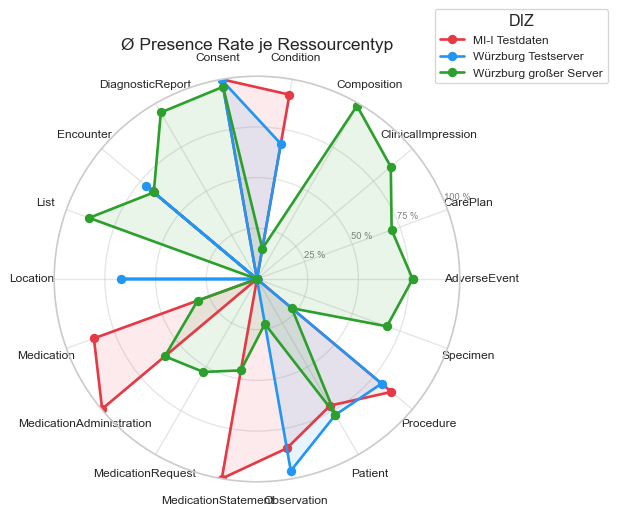

In [16]:
# ── 8a. Radar-Chart: Ø Presence Rate je Ressourcentyp & DIZ ──────────────
if not df_fields.empty and ALL_RT:
    scalar_fields = df_fields[
        ~df_fields["detected_python_types"].str.fullmatch(r"object|array", na=False)
    ].copy()

    avg_pr = (
        scalar_fields.groupby(["diz", "resource_type"])["presence_rate"]
        .mean()
        .unstack("resource_type")
        .reindex(columns=ALL_RT)
        .fillna(0)
    )

    N = len(ALL_RT)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for diz_name in LOADED_DIZ:
        if diz_name not in avg_pr.index:
            continue
        values = avg_pr.loc[diz_name].tolist()
        values += values[:1]
        ax.plot(angles, values, "o-", linewidth=2, label=diz_name,
                color=MPL_COLOR_MAP[diz_name])
        ax.fill(angles, values, alpha=0.1, color=MPL_COLOR_MAP[diz_name])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(ALL_RT, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["25 %", "50 %", "75 %", "100 %"], size=7, color="grey")
    ax.set_title("Ø Presence Rate je Ressourcentyp", size=13, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.38, 1.18), title="DIZ", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Felddaten verfügbar.")

### 8b. Feldvollständigkeit je Ressourcentyp — gestapelte Balken

Felder werden in vier Klassen eingeteilt: **immer** (100 %), **häufig** (≥ 50 %), **selten** (0–50 %), **nie** (0 %).  
Die Balkenlänge entspricht dem Anteil der Felder in jeder Klasse.

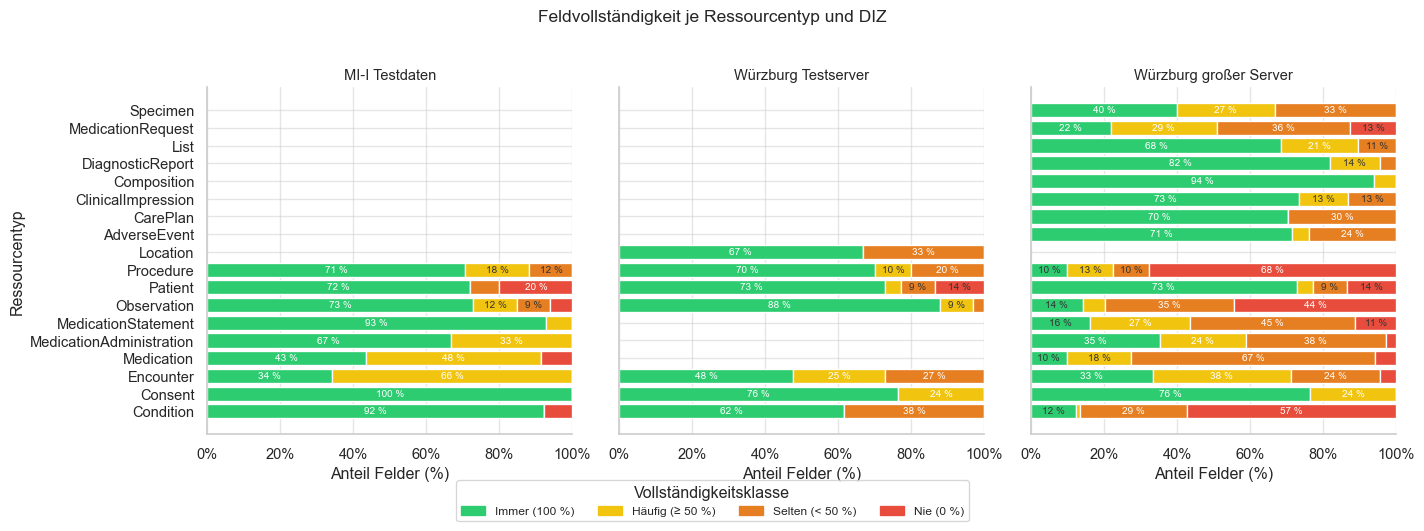

In [17]:
# ── 8b. Vollständigkeitsklassen je Ressourcentyp (gestapelte Balken) ──────
if not df_fields.empty:
    scalar_fields = df_fields[
        ~df_fields["detected_python_types"].str.fullmatch(r"object|array", na=False)
    ].copy()

    classes   = ["Immer (100 %)", "Häufig (≥ 50 %)", "Selten (< 50 %)", "Nie (0 %)"]
    cls_colors = ["#2ecc71",       "#f1c40f",           "#e67e22",          "#e74c3c"]

    def classify_pr(r):
        if r == 1.0:   return "Immer (100 %)"
        if r >= 0.5:   return "Häufig (≥ 50 %)"
        if r > 0:      return "Selten (< 50 %)"
        return "Nie (0 %)"

    scalar_fields["cls"] = scalar_fields["presence_rate"].apply(classify_pr)

    n_diz = len(LOADED_DIZ)
    fig, axes = plt.subplots(1, n_diz, figsize=(max(8, n_diz * 5), 5), sharey=True)
    if n_diz == 1:
        axes = [axes]

    for ax, diz_name in zip(axes, LOADED_DIZ):
        sub = scalar_fields[scalar_fields["diz"] == diz_name]
        counts = (
            sub.groupby(["resource_type", "cls"])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=classes, fill_value=0)
        )
        pct = counts.div(counts.sum(axis=1), axis=0) * 100

        left = np.zeros(len(pct))
        for cls, color in zip(classes, cls_colors):
            vals = pct[cls].values if cls in pct else np.zeros(len(pct))
            bars = ax.barh(pct.index, vals, left=left, color=color,
                           label=cls if diz_name == LOADED_DIZ[0] else "")
            for bar, v, l in zip(bars, vals, left):
                if v > 9:
                    ax.text(l + v / 2, bar.get_y() + bar.get_height() / 2,
                            f"{v:.0f} %", ha="center", va="center",
                            fontsize=7.5, color="white" if v > 18 else "#333")
            left = left + vals

        ax.set_xlim(0, 100)
        ax.set_xlabel("Anteil Felder (%)")
        ax.set_title(diz_name, size=11)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter())
        sns.despine(ax=ax)

    axes[0].set_ylabel("Ressourcentyp")
    handles = [mpatches.Patch(color=c, label=l) for c, l in zip(cls_colors, classes)]
    fig.legend(handles=handles, loc="lower center", ncol=4,
               bbox_to_anchor=(0.5, -0.06), fontsize=9, title="Vollständigkeitsklasse")
    fig.suptitle("Feldvollständigkeit je Ressourcentyp und DIZ", size=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Felddaten verfügbar.")

### 8c. Verteilung der Presence Rates — Histogramm + KDE

Wie viele Felder sind sehr selten befüllt, wie viele fast immer? Die Form der Kurve zeigt, ob ein DIZ viele obligatorische Felder hat oder eher spärlich dokumentiert.

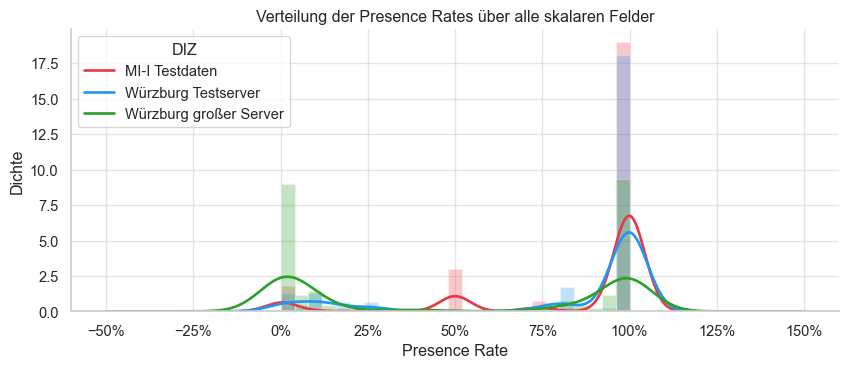

In [18]:
# ── 8c. Presence-Rate-Verteilung: Histogramm + KDE ───────────────────────
if not df_fields.empty:
    scalar_fields = df_fields[
        ~df_fields["detected_python_types"].str.fullmatch(r"object|array", na=False)
    ].copy()

    fig, ax = plt.subplots(figsize=(9, 4))

    for diz_name in LOADED_DIZ:
        pr = scalar_fields[scalar_fields["diz"] == diz_name]["presence_rate"].dropna()
        ax.hist(pr, bins=25, range=(0, 1), alpha=0.28,
                color=MPL_COLOR_MAP[diz_name], density=True)
        pr.plot.kde(ax=ax, bw_method=0.15, color=MPL_COLOR_MAP[diz_name],
                    linewidth=2, label=diz_name)

    ax.set_xlabel("Presence Rate")
    ax.set_ylabel("Dichte")
    ax.set_title("Verteilung der Presence Rates über alle skalaren Felder")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.legend(title="DIZ")
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Felddaten verfügbar.")

---
## 9. Kardinalitäts-Boxplots

Whisker-Boxplots aus den Perzentilspalten in `_cardinality.csv`.  
Box = P25–P75 · Mittelstrich = Median · Whisker = Min / P99 · **▲** = Mittelwert.  
Nur Ressourcentypen mit Coverage > 0 werden angezeigt.

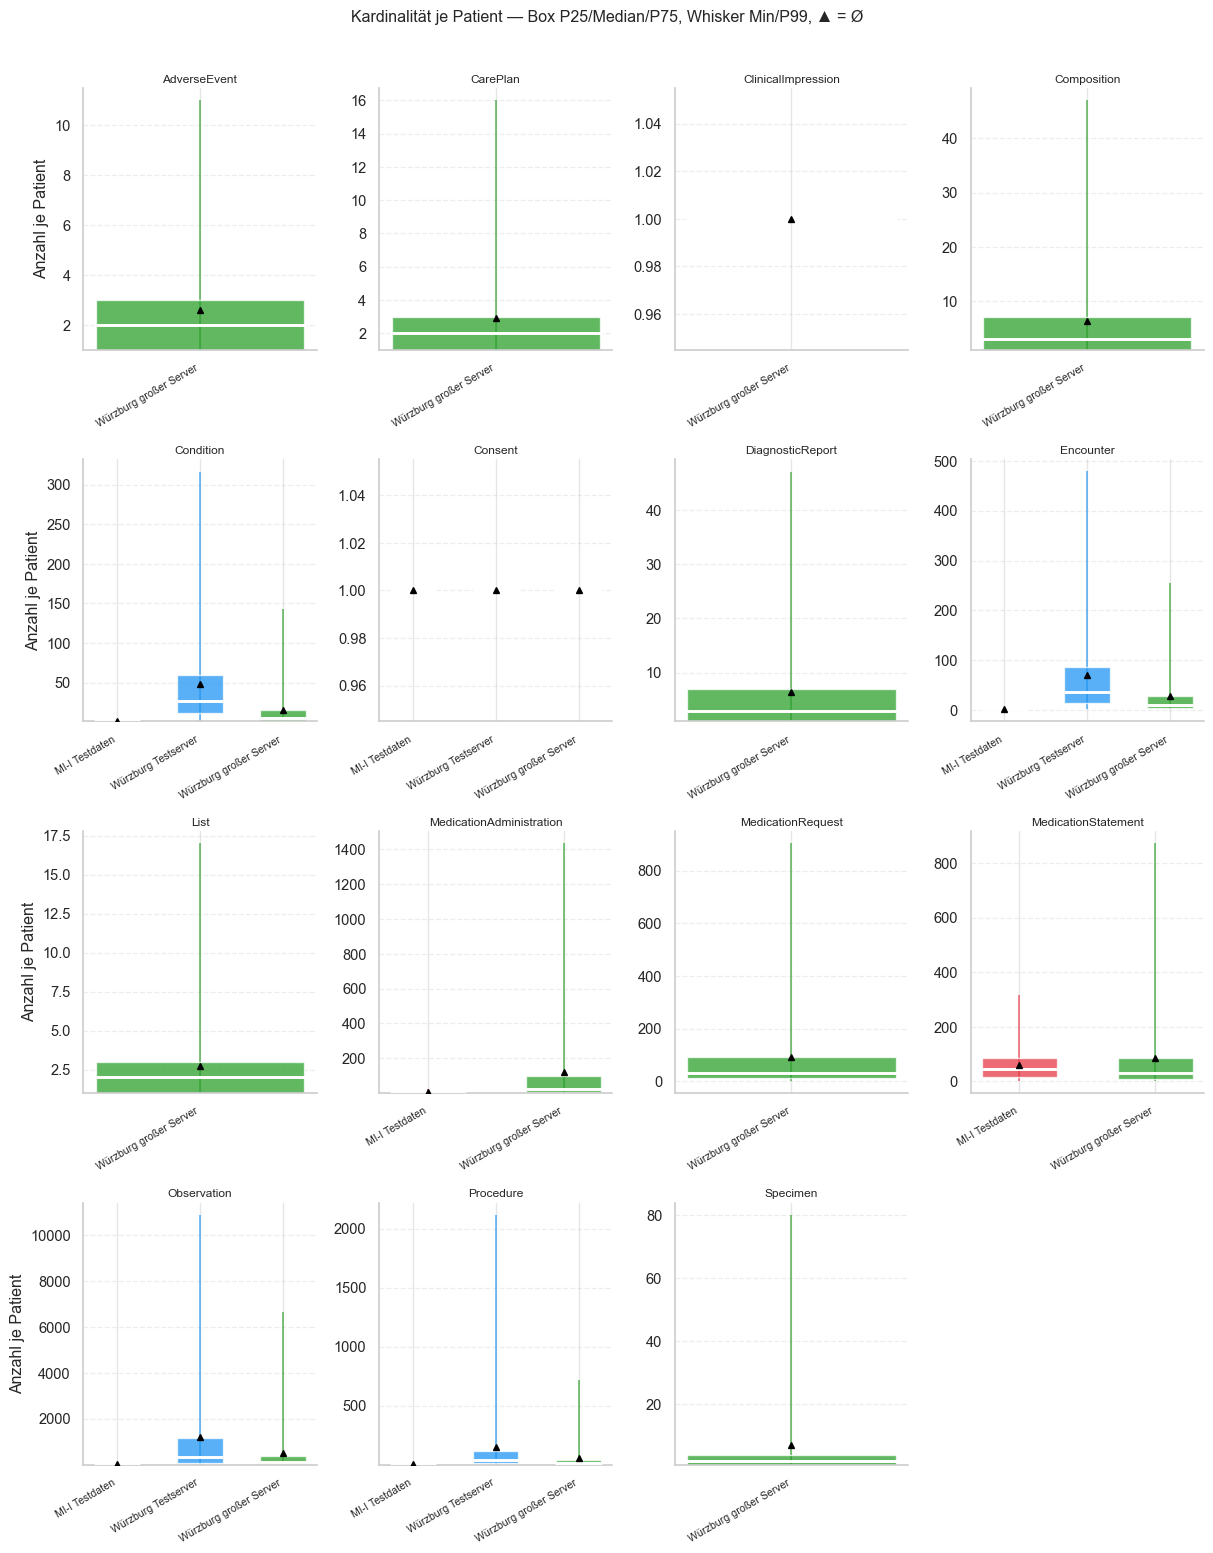

In [19]:
# ── 9. Kardinalitäts-Boxplots (per_patient, aus Perzentil-Daten) ──────────
if not df_card.empty and {"median", "p25", "p75", "min", "p99"}.issubset(df_card.columns):
    sub = df_card[
        (df_card["anchor_type"] == "per_patient") &
        (df_card["coverage_rate"] > 0)
    ].copy()

    resource_types = sorted(sub["resource_type"].unique())
    ncols = min(4, len(resource_types))
    nrows = (len(resource_types) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.2, nrows * 4),
                             squeeze=False)

    for idx, rt in enumerate(resource_types):
        ax = axes[idx // ncols][idx % ncols]
        rt_data = sub[sub["resource_type"] == rt].reset_index(drop=True)

        for i, row in rt_data.iterrows():
            diz = row["diz"]
            color = MPL_COLOR_MAP.get(diz, "steelblue")
            p25, med, p75 = row["p25"], row["median"], row["p75"]
            wlo, whi = row["min"], row["p99"]

            ax.vlines(i, wlo, whi, color=color, linewidth=1.5, zorder=1, alpha=0.6)
            ax.bar(i, p75 - p25, bottom=p25, width=0.55,
                   color=color, alpha=0.75, zorder=2)
            ax.hlines(med, i - 0.28, i + 0.28, color="white", linewidth=2.2, zorder=3)
            if "mean" in row and not pd.isna(row["mean"]):
                ax.plot(i, row["mean"], "^", color="black", ms=5, zorder=4)

        ax.set_xticks(range(len(rt_data)))
        ax.set_xticklabels(rt_data["diz"].tolist(), rotation=30, ha="right", size=8)
        ax.set_title(rt, size=9, pad=4)
        ax.set_ylabel("Anzahl je Patient" if idx % ncols == 0 else "")
        ax.grid(axis="y", alpha=0.35, linestyle="--")
        sns.despine(ax=ax)

    # Leere Achsen ausblenden
    for idx in range(len(resource_types), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Kardinalität je Patient — Box P25/Median/P75, Whisker Min/P99, ▲ = Ø",
                 size=12, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Kardinalitätsdaten fehlen oder unvollständig.")

---
## 10. DIZ-Korrelationsanalyse

### 10a. Korrelations-Heatmap

Pearson-Korrelation der Presence Rates zwischen allen DIZ-Paaren.  
Werte nahe **1.0** = sehr ähnliche Befüllungsstruktur.

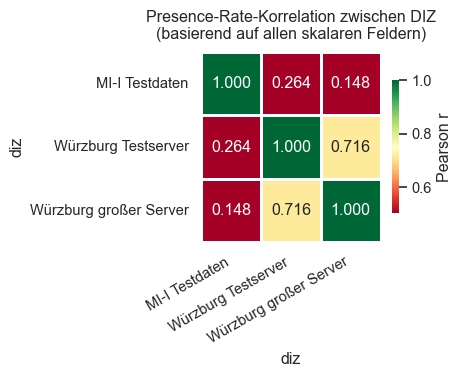

In [20]:
# ── 10a. Korrelations-Heatmap zwischen DIZ ───────────────────────────────
if not df_fields.empty and len(LOADED_DIZ) >= 2:
    scalar_fields = df_fields[
        ~df_fields["detected_python_types"].str.fullmatch(r"object|array", na=False)
    ].copy()

    pivot_corr = scalar_fields.pivot_table(
        index=["resource_type", "field_path"], columns="diz",
        values="presence_rate", aggfunc="first"
    ).reindex(columns=LOADED_DIZ)

    corr = pivot_corr.corr()
    size = max(4, len(LOADED_DIZ) * 1.6)

    fig, ax = plt.subplots(figsize=(size, size * 0.85))
    mask = np.zeros_like(corr, dtype=bool)
    np.fill_diagonal(mask, False)

    sns.heatmap(
        corr, annot=True, fmt=".3f", cmap="RdYlGn",
        vmin=0.5, vmax=1.0, linewidths=0.8,
        annot_kws={"size": 12},
        ax=ax, cbar_kws={"label": "Pearson r", "shrink": 0.7}
    )
    ax.set_title("Presence-Rate-Korrelation zwischen DIZ\n(basierend auf allen skalaren Feldern)",
                 size=12, pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()
elif len(LOADED_DIZ) < 2:
    print("Mindestens 2 DIZ für Korrelationsanalyse erforderlich.")
else:
    print("Keine Felddaten verfügbar.")

### 10b. Scatter: Presence Rate DIZ-Paare

Jeder Punkt entspricht einem Feld, Farbe = Ressourcentyp.  
Punkte **auf der Diagonalen** = beide DIZ haben dieselbe Rate.  
Punkte **oben links** = DIZ B befüllt das Feld häufiger als DIZ A (und umgekehrt).

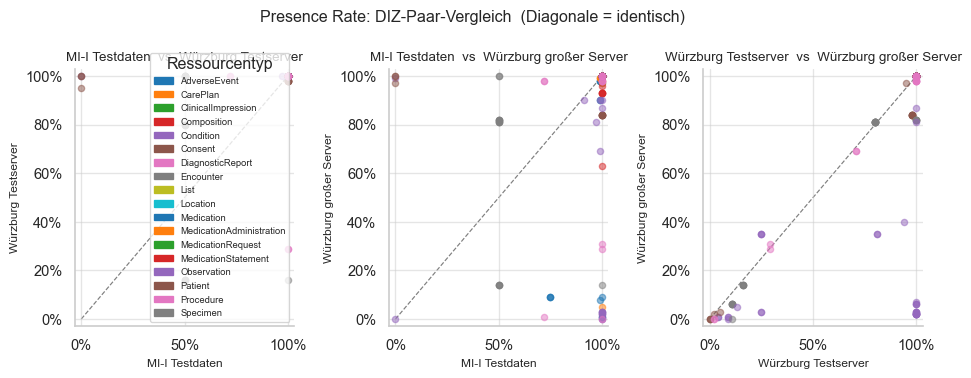

In [21]:
# ── 10b. Scatter: Presence Rate DIZ-Paar-Vergleich ───────────────────────
if not df_fields.empty and len(LOADED_DIZ) >= 2:
    scalar_fields = df_fields[
        ~df_fields["detected_python_types"].str.fullmatch(r"object|array", na=False)
    ].copy()

    pivot_sc = scalar_fields.pivot_table(
        index=["resource_type", "field_path"], columns="diz",
        values="presence_rate", aggfunc="first"
    ).reindex(columns=LOADED_DIZ).reset_index()

    pairs = [(LOADED_DIZ[i], LOADED_DIZ[j])
             for i in range(len(LOADED_DIZ))
             for j in range(i + 1, len(LOADED_DIZ))]

    rt_palette = dict(zip(ALL_RT, sns.color_palette("tab10", len(ALL_RT))))

    ncols = min(3, len(pairs))
    nrows = (len(pairs) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(min(ncols * 4.2, 10), nrows * 4.0),
                             squeeze=False)

    for idx, (diz_a, diz_b) in enumerate(pairs):
        ax = axes[idx // ncols][idx % ncols]
        for rt in ALL_RT:
            sub = pivot_sc[pivot_sc["resource_type"] == rt]
            if diz_a not in sub.columns or diz_b not in sub.columns:
                continue
            valid = sub[[diz_a, diz_b]].dropna()
            ax.scatter(valid[diz_a], valid[diz_b],
                       color=rt_palette.get(rt, "grey"),
                       alpha=0.5, s=22, label=rt, zorder=2)

        ax.plot([0, 1], [0, 1], "--", color="grey", lw=0.9, zorder=0)
        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(-0.03, 1.03)
        ax.set_xlabel(diz_a, size=9)
        ax.set_ylabel(diz_b, size=9)
        ax.set_title(f"{diz_a}  vs  {diz_b}", size=10)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        sns.despine(ax=ax)

    # Ressourcentyp-Legende in das erste Subplot
    handles = [mpatches.Patch(color=rt_palette.get(rt, "grey"), label=rt) for rt in ALL_RT]
    axes[0][0].legend(handles=handles, loc="lower right", fontsize=7, title="Ressourcentyp")

    # Leere Achsen ausblenden
    for idx in range(len(pairs), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Presence Rate: DIZ-Paar-Vergleich  (Diagonale = identisch)", size=12)
    plt.tight_layout()
    plt.show()
elif len(LOADED_DIZ) < 2:
    print("Mindestens 2 DIZ für Paar-Scatter erforderlich.")
else:
    print("Keine Felddaten verfügbar.")

---
## 11. Typ-Inkonsistenzen

Felder, bei denen dasselbe FHIR-Feld in verschiedenen Ressourcen mit **unterschiedlichem Python-Typ** auftaucht (z. B. `string` und `int`).  
Gestapelter Balken: Anteil inkonsistenter vs. konsistenter Felder je Ressourcentyp.

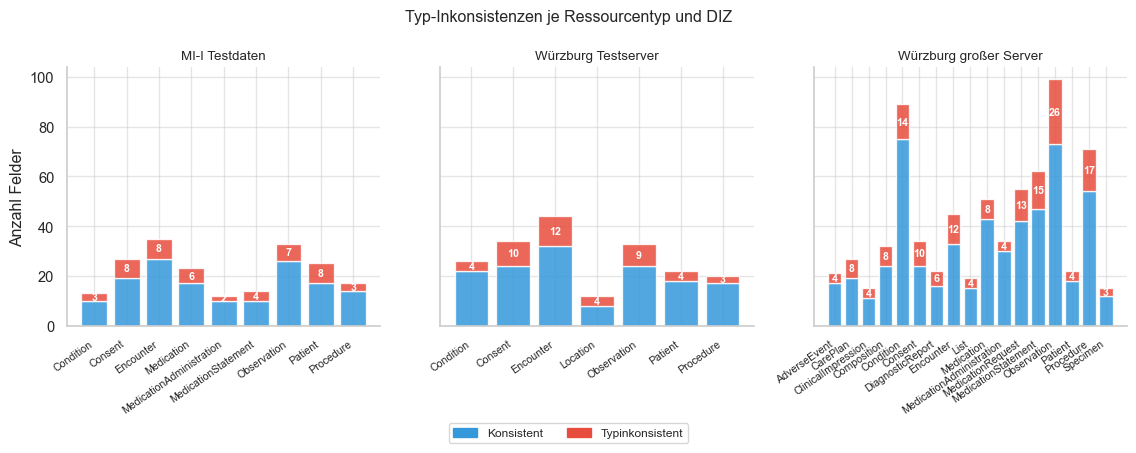


255 inkonsistente Felder:


,diz,resource_type,field_path,detected_python_types,presence_rate
0,Würzburg großer Server,AdverseEvent,AdverseEvent.event.coding[],"array, object",0.030
1,Würzburg großer Server,AdverseEvent,AdverseEvent.meta.profile[],"array, string",1.000
2,Würzburg großer Server,AdverseEvent,AdverseEvent.seriousness.coding[],"array, object",1.000
3,Würzburg großer Server,AdverseEvent,AdverseEvent.suspectEntity[],"array, object",1.000
4,Würzburg großer Server,CarePlan,CarePlan.activity[],"object, array",0.010
...,...,...,...,...,...
250,Würzburg großer Server,Procedure,Procedure.usedCode[],"object, array",0.000
251,Würzburg großer Server,Procedure,Procedure.usedCode[].coding[],"array, object",0.000
252,Würzburg großer Server,Specimen,Specimen.identifier[],"array, object",0.190
253,Würzburg großer Server,Specimen,Specimen.meta.profile[],"array, string",1.000


In [22]:
# ── 11. Typ-Inkonsistenzen: gestapelter Balken pro DIZ ───────────────────
if not df_fields.empty and "type_inconsistency" in df_fields.columns:
    scalar_fields = df_fields[
        ~df_fields["detected_python_types"].str.fullmatch(r"object|array", na=False)
    ].copy()
    scalar_fields["type_inconsistency"] = scalar_fields["type_inconsistency"].astype(bool)

    inc_summary = (
        scalar_fields.groupby(["diz", "resource_type"])
        .agg(total=("field_path", "nunique"),
             inconsistent=("type_inconsistency", "sum"))
        .reset_index()
    )
    inc_summary["consistent"] = inc_summary["total"] - inc_summary["inconsistent"]

    n_diz = len(LOADED_DIZ)
    fig, axes = plt.subplots(1, n_diz, figsize=(max(7, n_diz * 4), 4.5), sharey=True)
    if n_diz == 1:
        axes = [axes]

    for ax, diz_name in zip(axes, LOADED_DIZ):
        sub = inc_summary[inc_summary["diz"] == diz_name].sort_values("resource_type")
        x = np.arange(len(sub))

        b1 = ax.bar(x, sub["consistent"], color="#3498db", alpha=0.85, label="Konsistent")
        b2 = ax.bar(x, sub["inconsistent"], bottom=sub["consistent"].values,
                    color="#e74c3c", alpha=0.85, label="Typinkonsistent")

        for bar, val, bot in zip(b2, sub["inconsistent"].values, sub["consistent"].values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bot + val / 2,
                        str(int(val)), ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(sub["resource_type"].tolist(), rotation=35, ha="right", size=8)
        ax.set_title(diz_name, size=10)
        ax.set_ylabel("Anzahl Felder" if diz_name == LOADED_DIZ[0] else "")
        sns.despine(ax=ax)

    handles = [
        mpatches.Patch(color="#3498db", label="Konsistent"),
        mpatches.Patch(color="#e74c3c", label="Typinkonsistent"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=2,
               bbox_to_anchor=(0.5, -0.04), fontsize=9)
    fig.suptitle("Typ-Inkonsistenzen je Ressourcentyp und DIZ", size=12)
    plt.tight_layout()
    plt.show()

    # Detailliste
    inc_fields = scalar_fields[scalar_fields["type_inconsistency"]][
        ["diz", "resource_type", "field_path", "detected_python_types", "presence_rate"]
    ].sort_values(["resource_type", "field_path", "diz"])

    if not inc_fields.empty:
        print(f"\n{len(inc_fields)} inkonsistente Felder:")
        display(inc_fields.reset_index(drop=True))
    else:
        print("Keine Typ-Inkonsistenzen gefunden.")
else:
    print("Spalte 'type_inconsistency' nicht gefunden.")